In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [2]:
delivery = pd.read_csv("C:/Users/udiit/OneDrive/delivery_time.csv")

delivery.head()

,Delivery Time,Sorting Time
0,21.00,10
1,13.50,4
2,19.75,6
3,24.00,9
4,29.00,10


In [3]:
delivery.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Delivery Time  21 non-null     float64
 1   Sorting Time   21 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 464.0 bytes


In [4]:
delivery.shape

(21, 2)

In [5]:
delivery.shape

(21, 2)

In [6]:
delivery.isnull().sum()

Delivery Time    0
Sorting Time     0
dtype: int64

# EDA


In [8]:
delivery.describe()


,Delivery Time,Sorting Time
count,21.000000,21.000000
mean,16.790952,6.190476
std,5.074901,2.542028
min,8.000000,2.000000
25%,13.500000,4.000000
50%,17.830000,6.000000
75%,19.750000,8.000000
max,29.000000,10.000000


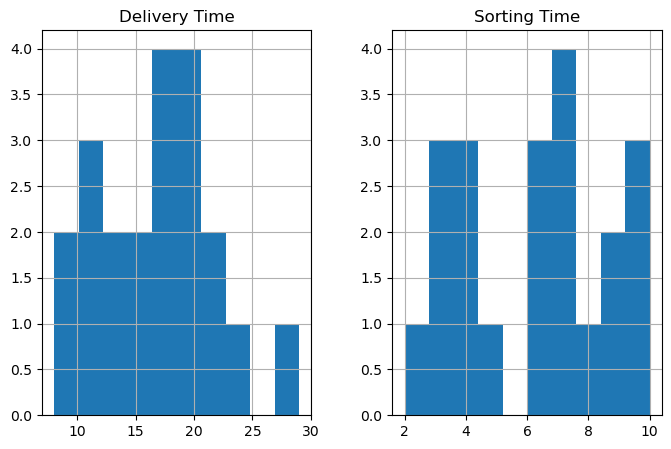

In [9]:
delivery.hist(figsize=(8,5))
plt.show()

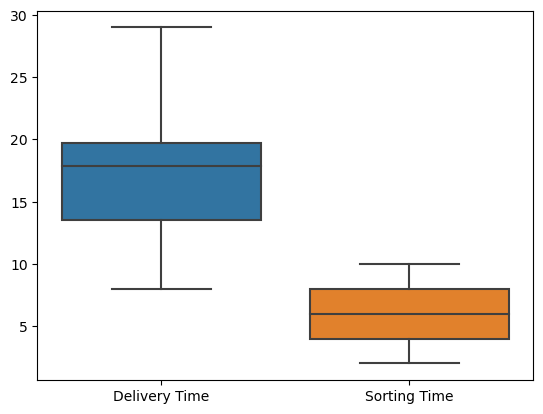

In [10]:
sns.boxplot(data=delivery)
plt.show()

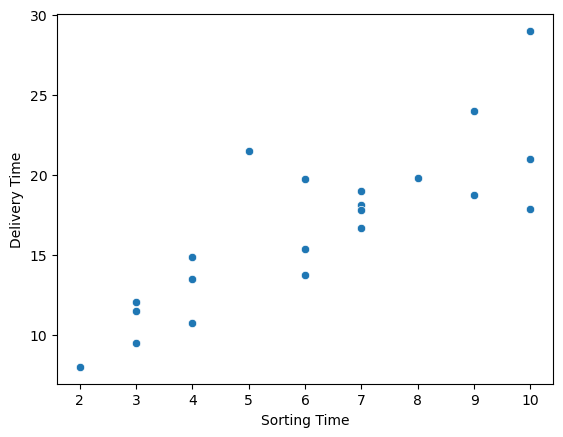

In [11]:
sns.scatterplot(
    x='Sorting Time',
    y='Delivery Time',
    data=delivery
)

plt.show()

# Correlation

In [12]:
delivery.corr()

,Delivery Time,Sorting Time
Delivery Time,1.000000,0.825997
Sorting Time,0.825997,1.000000


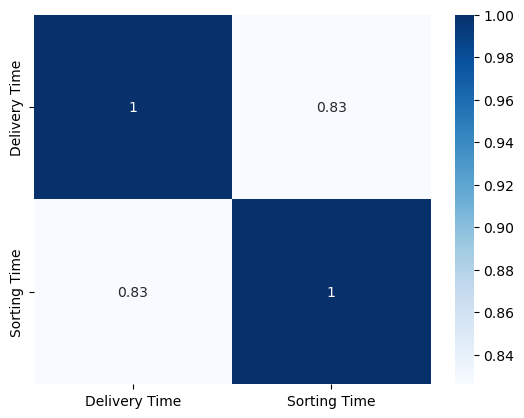

In [13]:
sns.heatmap(
    delivery.corr(),
    annot=True,
    cmap='Blues'
)

plt.show()

# Build Linear Regression Model

In [15]:
X = delivery[['Sorting Time']]
Y = delivery['Delivery Time']

In [16]:
model = LinearRegression()

model.fit(X,Y)

LinearRegression()

In [17]:
pred = model.predict(X)

In [19]:
r2 = r2_score(Y,pred)

print(r2)
#R² Score

0.6822714748417231


In [20]:
#RMSE
rmse = np.sqrt(mean_squared_error(Y,pred))

print(rmse)

2.7916503270617654


# Transformations

In [22]:
#LOG TRANSFORMATION - 

delivery["log_delivery"] = np.log(delivery["Delivery Time"])

model_log = LinearRegression()

model_log.fit(
    X,
    delivery["log_delivery"]
)

pred_log = model_log.predict(X)

r2_log = r2_score(
    delivery["log_delivery"],
    pred_log
)

print(r2_log)

0.7109478980584186


In [23]:
#Square Root Transformation

delivery["sqrt_delivery"] = np.sqrt(delivery["Delivery Time"])

model_sqrt = LinearRegression()

model_sqrt.fit(
    X,
    delivery["sqrt_delivery"]
)

pred_sqrt = model_sqrt.predict(X)

r2_sqrt = r2_score(
    delivery["sqrt_delivery"],
    pred_sqrt
)

print(r2_sqrt)

0.704049871541756


In [24]:
#Compare - creating table

results = pd.DataFrame({
    "Model":[
        "Original",
        "Log",
        "Sqrt"
    ],
    "R2":[
        r2,
        r2_log,
        r2_sqrt
    ]
})

results

,Model,R2
0,Original,0.682271
1,Log,0.710948
2,Sqrt,0.704050


In [25]:
#Predicting New values - 

new_data = pd.DataFrame({
    "Sorting Time":[5,8,12]
})

prediction = model.predict(new_data)

prediction

array([14.82783346, 19.77489315, 26.37097273])

In [26]:
#SAVING PREDICTIONS _ NEW VALUES - 

pred_df = pd.DataFrame({
    "Sorting Time":[5,8,12],
    "Predicted Delivery Time":prediction
})

pred_df.to_csv(
    "delivery_predictions.csv",
    index=False
)

# Problem 2: Salary Prediction

In [28]:
salary = pd.read_csv("C:/Users/udiit/OneDrive/Salary_Data.csv")

salary.head() 

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [29]:
salary.info()

salary.isnull().sum()

salary.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


0

In [30]:
salary.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


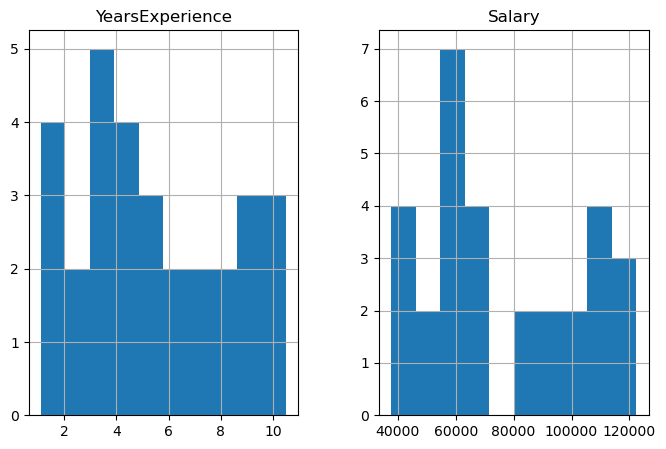

In [31]:
#Histogram - 

salary.hist(figsize=(8,5))
plt.show()

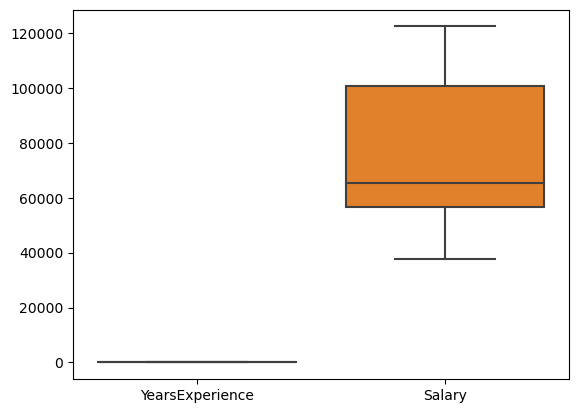

In [32]:
#Box Plot - 
sns.boxplot(data=salary)
plt.show()

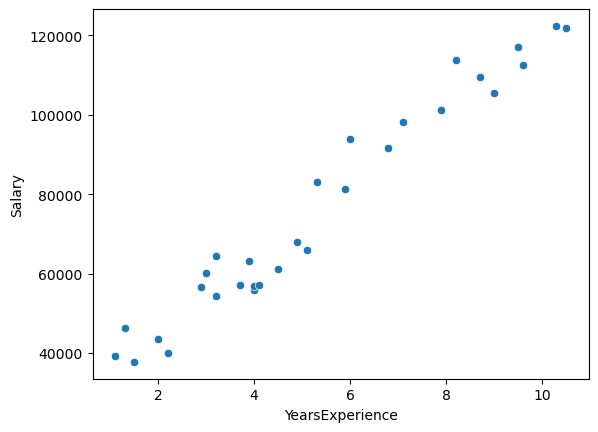

In [33]:
#Scatter Plot - 

sns.scatterplot(
    x='YearsExperience',
    y='Salary',
    data=salary
)

plt.show()

In [35]:
#correlation - 

salary.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


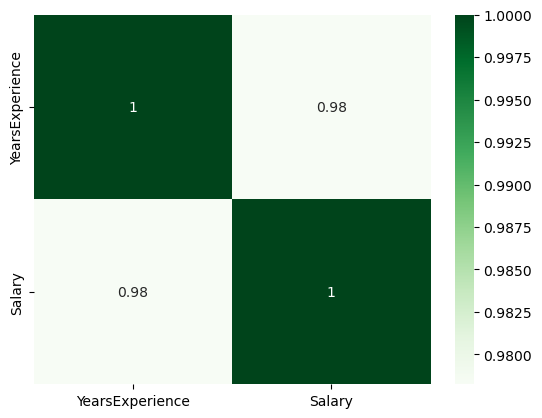

In [36]:
# Heatmap

sns.heatmap(
    salary.corr(),
    annot=True,
    cmap='Greens'
)

plt.show()

In [38]:
# Model - 

X = salary[['YearsExperience']]

Y = salary['Salary']

In [39]:
model = LinearRegression()

model.fit(X,Y)

LinearRegression()

In [40]:
pred = model.predict(X)

In [41]:
r2 = r2_score(Y,pred)

print(r2)

0.9569566641435086


In [42]:
rmse = np.sqrt(mean_squared_error(Y,pred))

print(rmse)

5592.043608760662


In [43]:
#Transformations - LOG SALARY : 

salary['log_salary'] = np.log(
    salary['Salary']
)

model_log = LinearRegression()

model_log.fit(
    X,
    salary['log_salary']
)

pred_log = model_log.predict(X)

r2_log = r2_score(
    salary['log_salary'],
    pred_log
)

print(r2_log)

0.9319671194084195


In [44]:
#SQ.root

salary['sqrt_salary'] = np.sqrt(
    salary['Salary']
)

model_sqrt = LinearRegression()

model_sqrt.fit(
    X,
    salary['sqrt_salary']
)

pred_sqrt = model_sqrt.predict(X)

r2_sqrt = r2_score(
    salary['sqrt_salary'],
    pred_sqrt
)

print(r2_sqrt)

0.949835353386529


In [45]:
#Comparing Models 

results = pd.DataFrame({
    "Model":[
        "Original",
        "Log",
        "Sqrt"
    ],
    "R2":[
        r2,
        r2_log,
        r2_sqrt
    ]
})

results

,Model,R2
0,Original,0.956957
1,Log,0.931967
2,Sqrt,0.949835


In [46]:
#Predictions - 

new_emp = pd.DataFrame({
    "YearsExperience":[3,7,12]
})

salary_pred = model.predict(
    new_emp
)

salary_pred

array([ 54142.08716303,  91941.93644885, 139191.74805613])

In [47]:
new_emp = pd.DataFrame({
    "YearsExperience":[3,7,12]
})

salary_pred = model.predict(
    new_emp
)

salary_pred

array([ 54142.08716303,  91941.93644885, 139191.74805613])